loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Plastic-Detection-Dataset-1 in yolov8:: 100%|██████████| 408/408 [00:00<00:00, 675.53it/s]


Dataset downloaded to: d:\One Drive\OneDrive\Desktop\SVu\Plastic-Detection-in-Water-Resources\Plastic-Detection-Dataset-1
Preparing training data...


Processing Training Images: 100%|██████████| 168/168 [00:20<00:00,  8.01it/s]


Data preparation complete. Total samples: 2839
Training the Linear SVM classifier...
Training complete.

--- Classifier Evaluation ---
Classification Report:
              precision    recall  f1-score   support

 Not Plastic       0.96      0.98      0.97       281
     Plastic       0.98      0.96      0.97       287

    accuracy                           0.97       568
   macro avg       0.97      0.97      0.97       568
weighted avg       0.97      0.97      0.97       568

Confusion Matrix:
[[275   6]
 [ 12 275]]
--------------------------

Running prediction on test images...
Processing 20200220_164341_jpg.rf.07de5ceb8584b09ff601849c34a4d338.jpg...
Processing 20200220_164345_jpg.rf.a003cd89bfc3c42057e24c88a45d6fd4.jpg...
Processing 20200228_154156_jpg.rf.1d0b31d05c88689a2890540f16ce4027.jpg...
Processing 20200228_154209_jpg.rf.ee24e1aad4cff40dd0b0937dd25f8616.jpg...
Processing 84119389_646896645878995_4311180913506516992_n_jpg.rf.b00a26f3ffac834537959a5bd984c9fd.jpg...
Processi

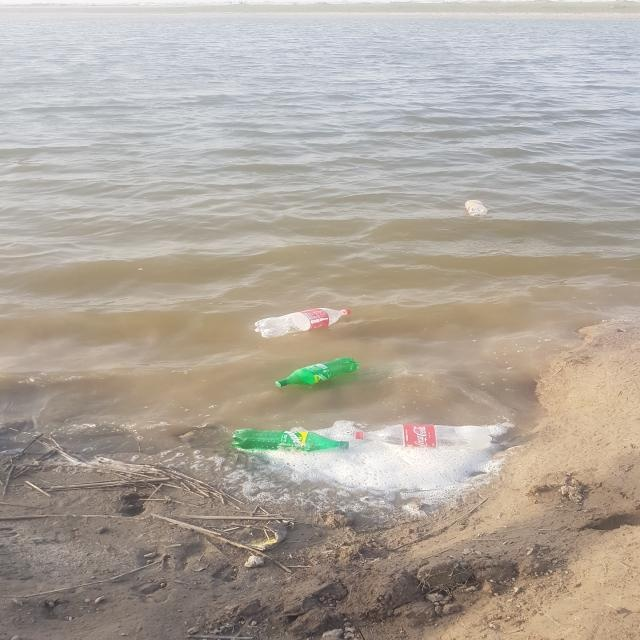



Displaying result for: 20200220_164345_jpg.rf.a003cd89bfc3c42057e24c88a45d6fd4.jpg


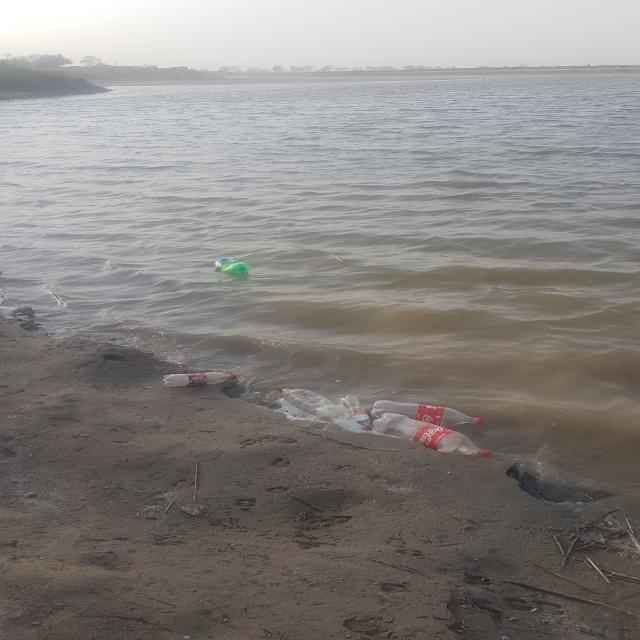



Displaying result for: 20200228_154156_jpg.rf.1d0b31d05c88689a2890540f16ce4027.jpg


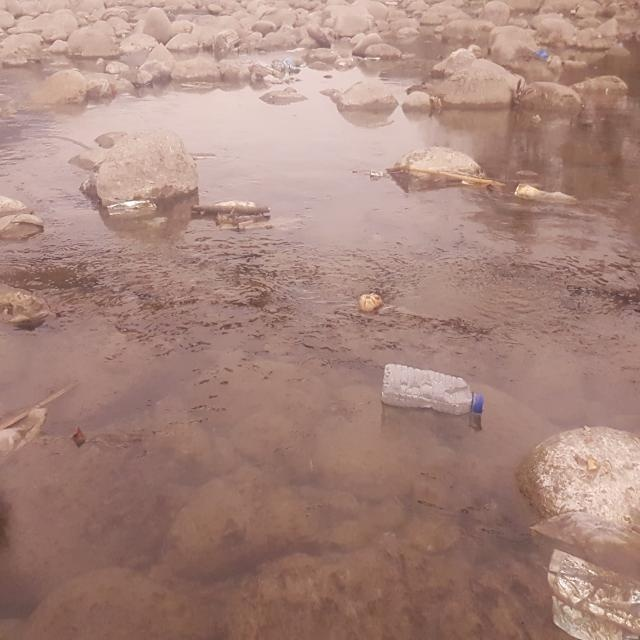



Displaying result for: 20200228_154209_jpg.rf.ee24e1aad4cff40dd0b0937dd25f8616.jpg


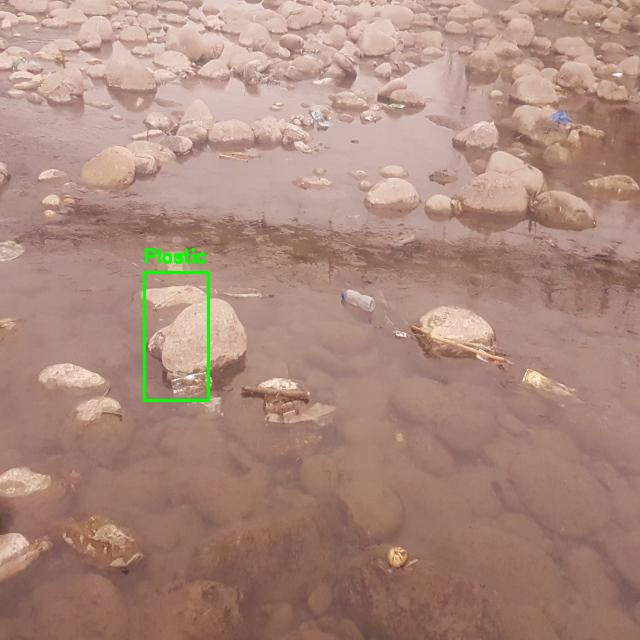



Displaying result for: 84119389_646896645878995_4311180913506516992_n_jpg.rf.b00a26f3ffac834537959a5bd984c9fd.jpg


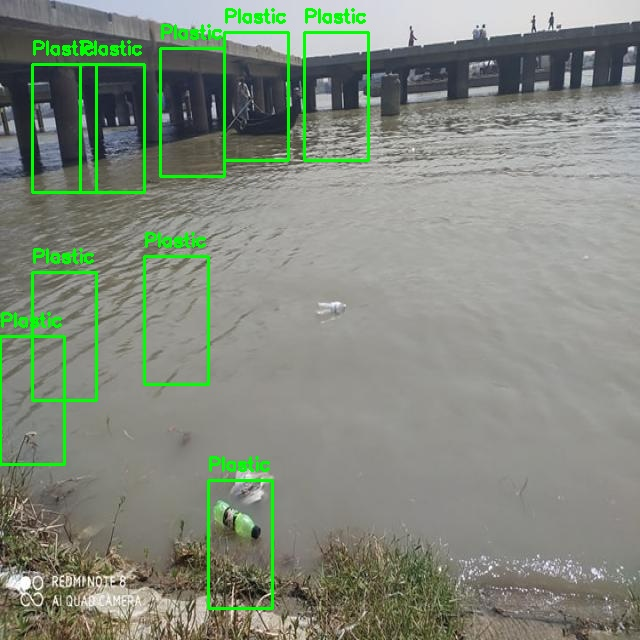



Displaying result for: DCSS7801_jpg.rf.a9d7a10caa09dc11481cb59dedcb3fbb.jpg


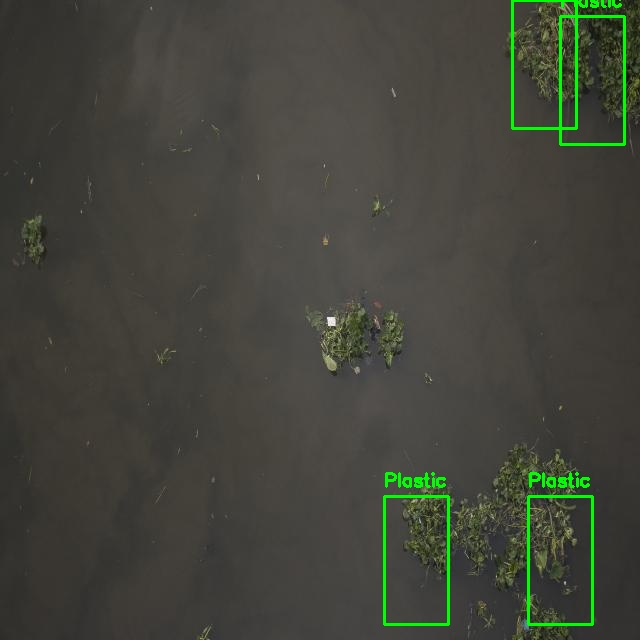



Displaying result for: DCSS7941_jpg.rf.ab7ec695cfded1fcf4256703156ebf34.jpg


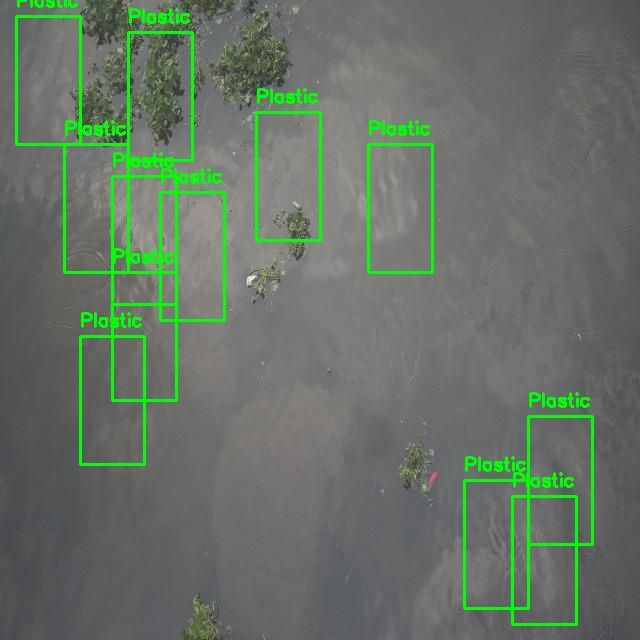



Displaying result for: IMG20200218113211_jpg.rf.1d503033e5c7300591a02ed8a30c811d.jpg


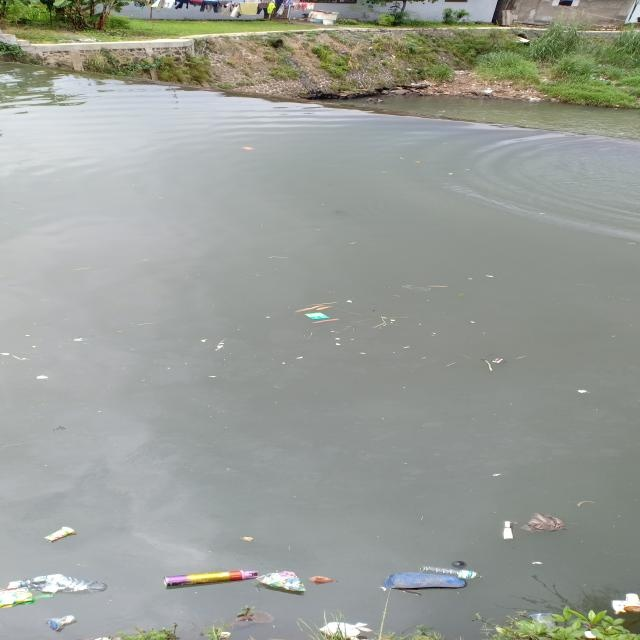



Displaying result for: IMG20200221125802_jpg.rf.7fed8aa2fe5213c49f634f9a18e8a2f1.jpg


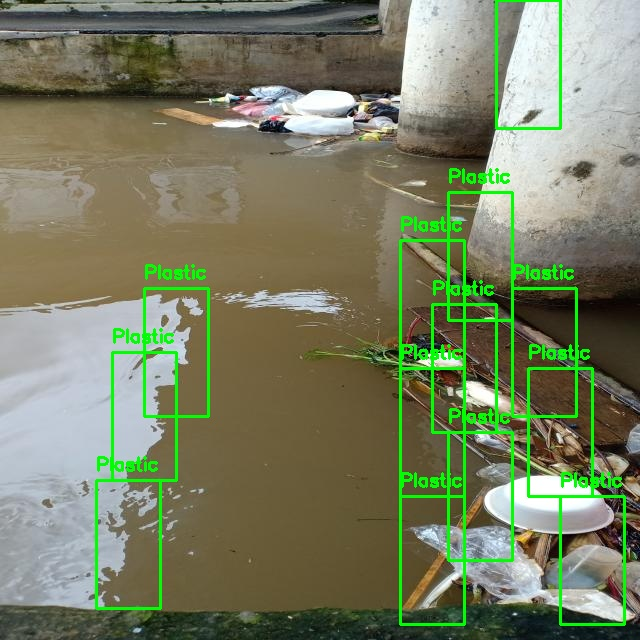



Displaying result for: IMG_20200222_131407_jpg.rf.bab12f63a4981e7f0c11a04116a5ccc3.jpg


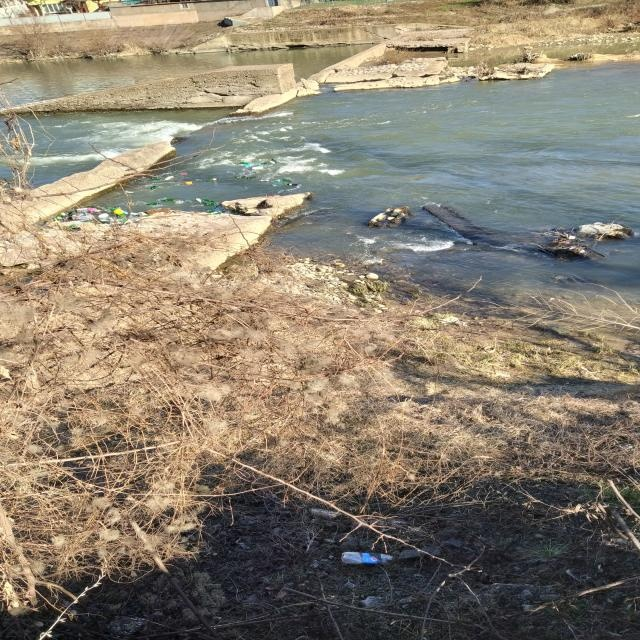

In [1]:
!pip install scikit-learn scikit-image opencv-python-headless roboflow tqdm

import os
import cv2
import glob
import random
from skimage.feature import hog
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
from tqdm import tqdm
from roboflow import Roboflow
from IPython.display import display, Image

# -- Helper Functions --

# Function to parse YOLO label files
def parse_yolo_labels(label_path, img_width, img_height):
    """Reads a YOLO label file and returns a list of bounding boxes in (x1, y1, x2, y2) format."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            # class_id, x_center, y_center, width, height
            x_center = float(parts[1]) * img_width
            y_center = float(parts[2]) * img_height
            w = float(parts[3]) * img_width
            h = float(parts[4]) * img_height
            x1 = int(x_center - w / 2)
            y1 = int(y_center - h / 2)
            x2 = int(x_center + w / 2)
            y2 = int(y_center + h / 2)
            boxes.append((x1, y1, x2, y2))
    return boxes

# Function for the sliding window
def sliding_window(image, step_size, window_size):
    """Slide a window across the image."""
    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

# Function for non-maximum suppression to clean up bounding boxes
def non_max_suppression(boxes, overlap_thresh):
    """Merges overlapping bounding boxes."""
    if len(boxes) == 0:
        return []

    # Convert boxes to float for division
    boxes = np.array(boxes, dtype="float")

    pick = []
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        overlap = (w * h) / area[idxs[:last]]

        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlap_thresh)[0])))

    return boxes[pick].astype("int")

# Step 2: Download the dataset using Roboflow
# This part remains the same.
try:
    rf = Roboflow(api_key="gWg6CT0tm7WHxZT2GoDw")
    project = rf.workspace("digital-image-processing-k3cbl").project("plastic-detection-dataset")
    # Download in yolov8 format as it's easy to parse
    dataset = project.version(1).download("yolov8")
    DATASET_PATH = dataset.location
    print(f"Dataset downloaded to: {DATASET_PATH}")
except Exception as e:
    print(f"Could not download dataset. Please check your API key and connection: {e}")
    # Fallback for offline use if dataset is already in /content/
    DATASET_PATH = "/content/Plastic-Detection-Dataset-1"


# Step 3: Prepare Training Data (Positive and Negative Samples)
# We will extract features from patches of the training images.

# Define parameters
# We need a fixed size for our feature extractor
PATCH_SIZE = (64, 128)
NEG_SAMPLES_PER_IMAGE = 10

# Lists to store our features and labels
data = []
labels = []

print("Preparing training data...")
train_images_path = os.path.join(DATASET_PATH, "train/images")
train_labels_path = os.path.join(DATASET_PATH, "train/labels")

image_files = glob.glob(os.path.join(train_images_path, "*.jpg"))

for img_path in tqdm(image_files, desc="Processing Training Images"):
    # Load image in grayscale
    image = cv2.imread(img_path)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Get corresponding label path
    label_name = os.path.basename(img_path).replace(".jpg", ".txt")
    label_path = os.path.join(train_labels_path, label_name)

    # Get ground-truth boxes
    gt_boxes = parse_yolo_labels(label_path, image.shape[1], image.shape[0])

    # --- Create Positive Samples ---
    for (x1, y1, x2, y2) in gt_boxes:
        # Crop the positive patch
        positive_patch = gray_image[y1:y2, x1:x2]
        if positive_patch.size == 0:
            continue
        # Resize to our standard patch size
        resized_patch = cv2.resize(positive_patch, PATCH_SIZE)

        # Calculate HOG features
        hog_features = hog(resized_patch, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True)

        data.append(hog_features)
        labels.append(1) # Label 1 for "plastic"

    # --- Create Negative Samples ---
    for _ in range(NEG_SAMPLES_PER_IMAGE):
        # Get random coordinates
        h, w = gray_image.shape
        rand_x = random.randint(0, w - PATCH_SIZE[0])
        rand_y = random.randint(0, h - PATCH_SIZE[1])

        # Check if the random patch overlaps with any ground-truth box
        overlaps = False
        for (x1, y1, x2, y2) in gt_boxes:
            if not (rand_x > x2 or rand_x + PATCH_SIZE[0] < x1 or
                    rand_y > y2 or rand_y + PATCH_SIZE[1] < y1):
                overlaps = True
                break

        if not overlaps:
            # Crop negative patch
            negative_patch = gray_image[rand_y:rand_y+PATCH_SIZE[1], rand_x:rand_x+PATCH_SIZE[0]]

            # Calculate HOG features
            hog_features = hog(negative_patch, orientations=9, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True)

            data.append(hog_features)
            labels.append(0) # Label 0 for "not plastic"

print(f"Data preparation complete. Total samples: {len(data)}")

# Step 4: Train the Simple ML Model (Linear SVM)

print("Training the Linear SVM classifier...")

# Convert lists to numpy arrays
X = np.array(data)
y = np.array(labels)

# Split data into training and testing sets for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We use a Pipeline to first scale the data, then train the classifier
# StandardScaler is important for SVMs.
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, random_state=42, tol=1e-5, max_iter=2000))
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Training complete.")

# Step 5: Evaluate the Classifier
# This is equivalent to YOLO's validation mode.

print("\n--- Classifier Evaluation ---")
y_pred = model_pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Plastic", "Plastic"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("--------------------------\n")

# Step 6: Prediction on Test Images
# This is equivalent to YOLO's predict mode. We use a sliding window.

print("Running prediction on test images...")
test_dir = os.path.join(DATASET_PATH, 'test/images')
output_dir = 'runs/detect/predict_simple'
os.makedirs(output_dir, exist_ok=True)

for test_image_path in glob.glob(f'{test_dir}/*.jpg'):
    print(f"Processing {os.path.basename(test_image_path)}...")

    img = cv2.imread(test_image_path)
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    detections = []

    # Use a simple sliding window (in a real scenario, you'd use an image pyramid for multi-scale)
    (winW, winH) = PATCH_SIZE
    for (x, y, window) in sliding_window(gray_img, step_size=16, window_size=(winW, winH)):
        if window.shape[0] != winH or window.shape[1] != winW:
            continue

        # 1. Extract HOG features from the window
        features = hog(window, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True)

        # 2. Use the trained model to predict
        # We need to reshape features since we're predicting a single sample
        prediction = model_pipeline.predict(features.reshape(1, -1))

        # 3. If it's a "plastic" detection, save the window coordinates
        if prediction[0] == 1:
            # You can also use model_pipeline.decision_function to get a confidence score
            # and filter by a threshold for better results.
            detections.append((x, y, x + winW, y + winH))

    # Draw initial detections
    # for (x1, y1, x2, y2) in detections:
    #     cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # Use Non-Maximum Suppression to merge overlapping boxes
    final_boxes = non_max_suppression(detections, overlap_thresh=0.3)

    # Draw the final, cleaned-up boxes
    for (x1, y1, x2, y2) in final_boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, 'Plastic', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Save and display the result
    output_path = os.path.join(output_dir, os.path.basename(test_image_path))
    cv2.imwrite(output_path, img)


# Step 7: Display the prediction results

print("\n--- Prediction Results ---")
# Display the images with detected bounding boxes
for image_path in glob.glob(f'{output_dir}/*.jpg'):
    print(f"Displaying result for: {os.path.basename(image_path)}")
    display(Image(filename=image_path, height=600))
    print("\n")





